# Lab 1 — Getting hands-on with images
**Student name:** Mayar Waleed Nawas
**Course:** Computer Vision


In [1]:
import os
import numpy as np
from PIL import Image, ImageDraw
import cv2
os.makedirs("./outputs", exist_ok=True)
print("outputs folder is ready")

outputs folder is ready


In [2]:
print("NumPy version:", np.__version__)
print("OpenCV version:", cv2.__version__)

NumPy version: 2.4.4
OpenCV version: 4.13.0


# NumPy

In [3]:
import numpy as np
# 1) create an array
x = np.array([1, 2, 3])
print(x)
print('===============================')
# 2) basic math (vectorized)
y = x * 10
print(y)
print('=========== matrix A ====================')
# 3) matricies
# A = np.zeros((2, 2), dtype=np.uint8)
# A = np.array([[1, 2], [3, 4]])
A = np.array([1, 2])
print(A)
print('============ Rotation Matrix ===================')
# Rotation Matrix
R = np.array([[0, -1], [1, 0]])
print(R)
print('============== Dot product =================')
# Dot product
B = np.dot(R, A)
print(B)
print('============= B_prime ==================')
R_invers = np.array([[0, 1], [-1, 0]])
B_prime = np.dot(R_invers, B)
print(B_prime) # the same as A (origin matrix)
print('============ Shape function ===================')
# Shape function
print(A.shape)


[1 2 3]
[10 20 30]
=========== matrix A ====================
[1 2]
============ Rotation Matrix ===================
[[ 0 -1]
 [ 1  0]]
============== Dot product =================
[-2  1]
============= B_prime ==================
[1 2]
============ Shape function ===================
(2,)


# Pillow

(512, 512) RGB


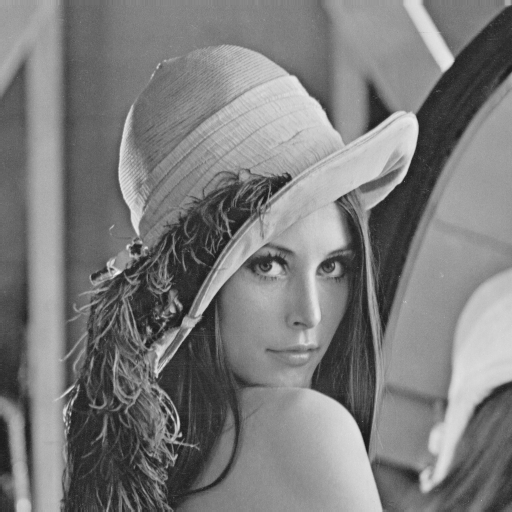

In [4]:
from PIL import Image
img = Image.open(".././data/lenna.png")
print(img.size, img.mode) # (width, height), and mode like 'RGB'
gray = img.convert("L") # L => means convert to grey
gray.save("./outputs/lenna_gray_pillow.png")
# Following line to view image in Jupyter
gray

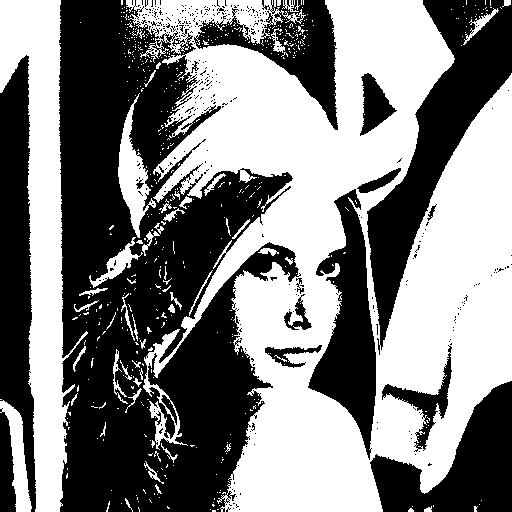

In [5]:
threshold = 128
img_thresholded = gray.point(lambda p: 255 if p > threshold else 0)
img_thresholded

# OpenCV

In [6]:
import cv2
img_bgr = cv2.imread(".././data/lenna.png")
print(img_bgr.shape) # (height, width, channels)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
cv2.imwrite("./outputs/lenna_gray_opencv.png", img_gray)

(512, 512, 3)


True

## Task Part A — Warm-up with NumPy (no Pillow/OpenCV yet)

### A1) Create a tiny black/white “image” as a matrix

In [7]:
import numpy as np
# 8x8 checkerboard: alternating 0 and 255
img0 = np.indices((8, 8)).sum(axis=0) % 2
# img0 = np.indices((3,2,7)) --> 3 => no.matrix , 2=> no.rows , 7=>no.columns

img0 = (img0 * 255).astype(np.uint8)
print("Original 8x8 checkerboard:")
print(img0)


Original 8x8 checkerboard:
[[  0 255   0 255   0 255   0 255]
 [255   0 255   0 255   0 255   0]
 [  0 255   0 255   0 255   0 255]
 [255   0 255   0 255   0 255   0]
 [  0 255   0 255   0 255   0 255]
 [255   0 255   0 255   0 255   0]
 [  0 255   0 255   0 255   0 255]
 [255   0 255   0 255   0 255   0]]


### Describe what you see: 
- How many unique values exist? 2
- What is the pattern? checkerboard


## create a vertical stripes pattern instead of a checkerboard

In [8]:
img1 = np.indices((8,8))[0]%2
img1 = (img1 * 255).astype(np.uint8)
print("Original 8x8 checkerboard:")
print(img1)

Original 8x8 checkerboard:
[[  0   0   0   0   0   0   0   0]
 [255 255 255 255 255 255 255 255]
 [  0   0   0   0   0   0   0   0]
 [255 255 255 255 255 255 255 255]
 [  0   0   0   0   0   0   0   0]
 [255 255 255 255 255 255 255 255]
 [  0   0   0   0   0   0   0   0]
 [255 255 255 255 255 255 255 255]]


### A2) Transformation 1 — scaling (upsampling)

In [9]:
# Reset to original each time
img = img0.copy()
scaled2 = np.kron(img, np.ones((2, 2), dtype=np.uint8))
print("\nScaled (x2) shape:", scaled2.shape)
print(scaled2)



Scaled (x2) shape: (16, 16)
[[  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [255 255   0   0 255 255   0   0 255 255   0   0 255 255   0   0]
 [255 255   0   0 255 255   0   0 255 255   0   0 255 255   0   0]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [255 255   0   0 255 255   0   0 255 255   0   0 255 255   0   0]
 [255 255   0   0 255 255   0   0 255 255   0   0 255 255   0   0]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [255 255   0   0 255 255   0   0 255 255   0   0 255 255   0   0]
 [255 255   0   0 255 255   0   0 255 255   0   0 255 255   0   0]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [  0   0 255 255   0   0 255 255   0   0 255 255   0   0 255 255]
 [255 255   0   0 255 255   0   0

### Describe what you see:
- What changed in the numbers? the number doubled for each row and column

- What changed in the size? the size doubled (16,16)

### try scaling by 3 instead of 2.

In [10]:
img3 = img0.copy()
scaled2 = np.kron(img3, np.ones((3, 3), dtype=np.uint8))
print("\nScaled (x2) shape:", scaled2.shape)
print(scaled2)


Scaled (x2) shape: (24, 24)
[[  0   0   0 255 255 255   0   0   0 255 255 255   0   0   0 255 255 255
    0   0   0 255 255 255]
 [  0   0   0 255 255 255   0   0   0 255 255 255   0   0   0 255 255 255
    0   0   0 255 255 255]
 [  0   0   0 255 255 255   0   0   0 255 255 255   0   0   0 255 255 255
    0   0   0 255 255 255]
 [255 255 255   0   0   0 255 255 255   0   0   0 255 255 255   0   0   0
  255 255 255   0   0   0]
 [255 255 255   0   0   0 255 255 255   0   0   0 255 255 255   0   0   0
  255 255 255   0   0   0]
 [255 255 255   0   0   0 255 255 255   0   0   0 255 255 255   0   0   0
  255 255 255   0   0   0]
 [  0   0   0 255 255 255   0   0   0 255 255 255   0   0   0 255 255 255
    0   0   0 255 255 255]
 [  0   0   0 255 255 255   0   0   0 255 255 255   0   0   0 255 255 255
    0   0   0 255 255 255]
 [  0   0   0 255 255 255   0   0   0 255 255 255   0   0   0 255 255 255
    0   0   0 255 255 255]
 [255 255 255   0   0   0 255 255 255   0   0   0 255 255 255 

### A3) Transformation 2 — rotation by 90 degrees

In [11]:
img = img0.copy()

rot90 = np.rot90(img, k=1) # 90 degrees counter-clockwise
print("\nRotated 90°:")
print(rot90)


Rotated 90°:
[[255   0 255   0 255   0 255   0]
 [  0 255   0 255   0 255   0 255]
 [255   0 255   0 255   0 255   0]
 [  0 255   0 255   0 255   0 255]
 [255   0 255   0 255   0 255   0]
 [  0 255   0 255   0 255   0 255]
 [255   0 255   0 255   0 255   0]
 [  0 255   0 255   0 255   0 255]]


### Describe what you see:
- Is the checkerboard different after 90° rotation? Why/why not?
Yes , cuz we make a rotation twice

###  rotate by 180° using NumPy.

In [12]:
img = img0.copy()
rot90 = np.rot90(img, k=2) # 180 degrees counter-clockwise
print("\nRotated 90°:")
print(rot90)


Rotated 90°:
[[  0 255   0 255   0 255   0 255]
 [255   0 255   0 255   0 255   0]
 [  0 255   0 255   0 255   0 255]
 [255   0 255   0 255   0 255   0]
 [  0 255   0 255   0 255   0 255]
 [255   0 255   0 255   0 255   0]
 [  0 255   0 255   0 255   0 255]
 [255   0 255   0 255   0 255   0]]


# Part B — Tasks with real images

### Task 1 — Read images (Pillow and OpenCV)

In [13]:
# 1A) Read with Pillow
from PIL import Image
img_pil = Image.open(".././data/lenna.png")
print("Pillow:")
print(" size (W,H):", img_pil.size)
print(" mode:", img_pil.mode)
# Optional display (opens default viewer)
img_pil.show()
# 1B) Read with OpenCV
import cv2
img_cv = cv2.imread(".././data/lenna.png") # BGR
print("OpenCV:")
print(" shape (H,W,C):", img_cv.shape)
print(" dtype:", img_cv.dtype)
cv2.imshow("Lenna (OpenCV)", img_cv)
cv2.waitKey(0)
cv2.destroyAllWindows()


Pillow:
 size (W,H): (512, 512)
 mode: RGB
OpenCV:
 shape (H,W,C): (512, 512, 3)
 dtype: uint8


### Describe what you see:
- Why does Pillow report size as (W,H) but OpenCV shape is (H,W,C)? The C means Channels (R,G,B - each color is a channel in open cv ) =3
So OpenCv need to know the channels to work with it with the images ,cuz each image is a matrix from pixels ,and each pixel contains a number (the channel  number)


###  load baboon.png with both libraries and print its size/shape.

Pillow:
 size (W,H): (512, 512)
 mode: RGB


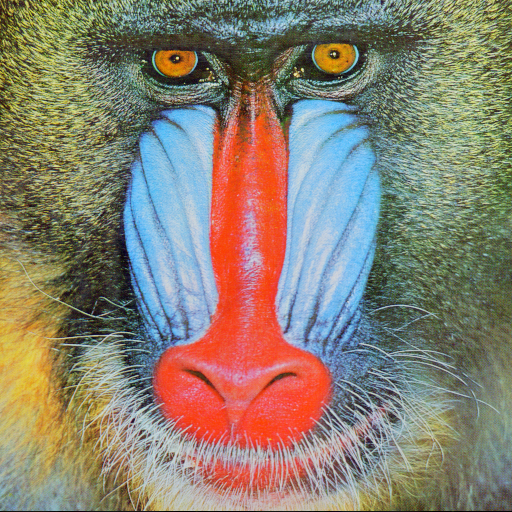

In [14]:
img_pil2 = Image.open(".././data/baboon.png")
print("Pillow:")
print(" size (W,H):", img_pil2.size)
print(" mode:", img_pil2.mode)
# Optional display (opens default viewer)
img_pil2

In [15]:
img_cv2 = cv2.imread(".././data/baboon.png") # BGR
print("OpenCV:")
print(" shape (H,W,C):", img_cv2.shape)
print(" dtype:", img_cv2.dtype)
cv2.imshow("Baboon (OpenCV)", img_cv2)
cv2.waitKey(0)
cv2.destroyAllWindows()

OpenCV:
 shape (H,W,C): (512, 512, 3)
 dtype: uint8


### Task 2 — Display images (and save outputs)

In [16]:
# Save a copy to confirm your pipeline works
img_pil.save("./outputs/lenna_copy_pillow.png")
# Display (may open a viewer window)
img_pil.show(title="Lenna (Pillow)")

# Display / save with OpenCV
cv2.imwrite("./outputs/lenna_copy_opencv.png", img_cv)# Display (requires a GUI)cv2.imshow("Lenna (OpenCV)", img_cv)
cv2.waitKey(0)
cv2.destroyAllWindows()

### Describe what you see:
- Are the saved images identical? Yes
- If you display with OpenCV, do the colors look correct? (Hint: BGR) Yeah the same color(RGB ), but if we try to open it in a differnt program that use RGB but the image is BGR , the color will be different

### save barbara.png to outputs with both libraries.

In [17]:
#pillow
img_pil3 = Image.open(".././data/barbara.png")
img_pil3.save("./outputs/barabra_copy_pillow.png")
img_pil3.show(title="Barabra (Pillow)")

# open_cv
img_cv3 = cv2.imread(".././data/barbara.png") # BGR

cv2.imwrite("./outputs/barabra_copy_opencv.png", img_cv3)
cv2.imshow("barabra (OpenCV)", img_cv3)
cv2.waitKey(0)
cv2.destroyAllWindows()

### Task 3 — Convert color (RGB/BGR and grayscale)

In [18]:
# 3A) Pillow: convert to grayscale
gray_pil = img_pil.convert("L")
print("Pillow grayscale mode:", gray_pil.mode)
gray_pil.save("./outputs/lenna_gray_pillow.png")

# 3B) OpenCV: BGR → grayscale
gray_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
print("OpenCV grayscale shape:", gray_cv.shape)
cv2.imwrite("./outputs/lenna_gray_opencv.png", gray_cv)

# 3C) OpenCV: BGR → RGB (useful for correct colors)
rgb_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
cv2.imwrite("./outputs/lenna_rgb_converted_from_opencv.png", rgb_cv)

Pillow grayscale mode: L
OpenCV grayscale shape: (512, 512)


True

### Describe what you see:
- What is the difference between a color image array and a grayscale array?  
color image array : shape => 3D ( H,W,3(channels) )  
grayscale : shape => 2D (H,W) , Single channel

### convert baboon.png to grayscale with both libraries

In [19]:
# 3A) Pillow: convert to grayscale
gray_pil_baboon = img_pil2.convert("L")
print("Pillow grayscale mode:", gray_pil_baboon.mode)
gray_pil_baboon.save("./outputs/baboon_gray_pillow.png")

# 3B) OpenCV: BGR → grayscale
gray_cv_baboon = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2GRAY)
print("OpenCV grayscale shape:", gray_cv_baboon.shape)
cv2.imwrite("./outputs/baboon_gray_opencv.png", gray_cv_baboon)

# 3C) OpenCV: BGR → RGB (useful for correct colors)
rgb_cv_baboon = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)
cv2.imwrite("./outputs/baboon_rgb_converted_from_opencv.png", rgb_cv_baboon)


Pillow grayscale mode: L
OpenCV grayscale shape: (512, 512)


True

### Task 4 — Inspect pixel values

In [20]:
# 4A) Pillow pixel inspection
# getpixel uses (x, y)
px00 = img_pil.getpixel((0, 0))
px10 = img_pil.getpixel((1, 0))
print("Pillow pixel (0,0):", px00)
print("Pillow pixel (1,0):", px10)

# 4B) OpenCV pixel inspection
# OpenCV array indexing is [y, x] and color is BGR
px00_cv = img_cv[0, 0]
px10_cv = img_cv[0, 1]
print("OpenCV pixel [0,0] (BGR):", px00_cv)
print("OpenCV pixel [0,1] (BGR):", px10_cv)

# 4C) Convert Pillow to NumPy and compare
import numpy as np
arr_pil = np.array(img_pil)  # RGB
print("NumPy from Pillow shape:", arr_pil.shape)
print("arr_pil[0,0] (RGB):", arr_pil[0, 0])

Pillow pixel (0,0): (226, 137, 125)
Pillow pixel (1,0): (226, 137, 125)
OpenCV pixel [0,0] (BGR): [125 137 226]
OpenCV pixel [0,1] (BGR): [125 137 226]
NumPy from Pillow shape: (512, 512, 3)
arr_pil[0,0] (RGB): [226 137 125]


### Describe what you see:
- Explain why img_pil.getpixel((x,y)) vs img_cv[y,x] looks “swapped”  
Cuz the first one is RGB and the second is BGR

- Explain why the color channel order differs.  
Cuz the first one is RGB and the second is BGR , openCV read BGR and Pillow read RGB  

##### important Note: Pillow depend on RGB, and Open CV depend on GBR 


### pick a pixel near the center and compare its values in Pillow vs OpenCV

In [21]:
# Pillow 
px256 = img_pil.getpixel((256, 256))
#Pillow handle RGB not BGR
print("Pillow pixel (256,256):", px256)

# Open CV
px256_cv = img_cv[256, 256]
#Open Cv handle BGR not RGP
print("OpenCV pixel [256,256] (BGR):", px256_cv)

Pillow pixel (256,256): (180, 65, 72)
OpenCV pixel [256,256] (BGR): [ 72  65 180]


### Task 5 — Apply simple transformations

In [22]:
# 5A) Pillow transformations
# Resize (scale down)
# img_pil.size => shape (512,512)
# // 2 => return float as integer (int)
small_pil = img_pil.resize((img_pil.size[0] // 2, img_pil.size[1] // 2))
small_pil.save("./outputs/lenna_small_pillow.png")# Rotate (degrees, around image center)
rot_pil = img_pil.rotate(30)  # default expands=False
rot_pil.save("./outputs/lenna_rot30_pillow.png")# Flip left-right
flip_pil = img_pil.transpose(Image.FLIP_LEFT_RIGHT)
flip_pil.save("./outputs/lenna_flip_lr_pillow.png")

# 5B) OpenCV transformations
h, w = img_cv.shape[:2]# Resize
small_cv = cv2.resize(img_cv, (w // 2, h // 2))
cv2.imwrite("./outputs/lenna_small_opencv.png", small_cv)# Rotate 90 degrees (built-in)
rot90_cv = cv2.rotate(img_cv, cv2.ROTATE_90_COUNTERCLOCKWISE)
cv2.imwrite("./outputs/lenna_rot90_opencv.png", rot90_cv)# Flip: 1=horizontal, 0=vertical, -1=both
flip_cv = cv2.flip(img_cv, 1)
cv2.imwrite("./outputs/lenna_flip_lr_opencv.png", flip_cv)

True

### Describe what you see:
- Which library was easier for rotation?  
Pillow transformations

### try a different rotation angle in OpenCV (hint: cv2.getRotationMatrix2D + cv2.warpAffine). Search it quickly in the official OpenCV tutorials

In [23]:
center=(w//2,h//2)
angle=90
scale=1
rot_mat = cv2.getRotationMatrix2D(center, angle, scale)
rotated = cv2.warpAffine(img_cv, rot_mat, (w, h))
cv2.imwrite("./outputs/lenna_flip_lr_opencv_rotated.png", flip_cv)

True

### Task 6 — Draw geometric shapes

In [24]:
# 6A) Pillow: draw on an image
from PIL import ImageDraw, Image

img = Image.open(".././data/lenna.png")
img_draw_pil = img.copy()
draw = ImageDraw.Draw(img_draw_pil)

# Rectangle: [(x0,y0), (x1,y1)]
draw.rectangle([(50, 50), (200, 200)], outline="red", width=3)

# Line: [(x0,y0), (x1,y1)]
draw.line([(0, 0), (img_draw_pil.size[0]-1, img_draw_pil.size[1]-1)], fill="yellow", 
width=3)

# Text
draw.text((60, 210), "Lab 1", fill="white")

img_draw_pil.save("./outputs/lenna_draw_pillow.png")
img_draw_pil.show()


# 6B) OpenCV: draw on an image
img_draw_cv = img_cv.copy()

# Rectangle: top-left, bottom-right
cv2.rectangle(img_draw_cv, (50, 50), (200, 200), (0, 0, 255), 3)  # red in BGR

# Line
h, w = img_draw_cv.shape[:2]
cv2.line(img_draw_cv, (0, 0), (w-1, h-1), (0, 255, 255), 3)  # yellow in BGR

# Text
cv2.putText(img_draw_cv, "Lab 1", (60, 230), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)

cv2.imwrite("./outputs/lenna_draw_opencv.png", img_draw_cv)

True

### Describe what you see:
- Why do we write colors as (B, G, R) tuples in OpenCV but use names like "red" in Pillow?  
Cuz Pillow is high level and user friendly so that why it use color name

### draw a circle around the center of the image using both libraries

In [25]:
# Pillow
draw.ellipse([(0,0),(150,150)],outline="red",width=3,fill="yellow")
img_draw_pil.save("./outputs/lenna_draw_pillow.png")
img_draw_pil.show()

# open cv 
cv2.circle(img_draw_cv,(447,63), 63, (0,0,255), -1)
cv2.imwrite("./outputs/lenna_draw_opencv.png", img_draw_cv)

True